# Importando Bibliotecas

In [1]:
import pandas as pd
from pandas.core import groupby
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import zscore
import pingouin as pg
from os import replace
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Lendo base de dados anonimizada

In [2]:
df = pd.read_excel('base_dados_anonimizada.xlsx')
df_copia = df.copy()

# Tratamento da base de dados anonimizada

## Tratamento de nulos e exclusão de variáveis irrelevantes

### Excluindo colunas

In [3]:
# 1. Definimos a lista exata de colunas que queremos remover
colunas_para_excluir = ["REVENDA", "SITUACAO", "DESLOCAMENTO", "SERVICO GUINCHO"]

# 2. Exclusão das colunas
df = df.drop(columns=colunas_para_excluir, errors="ignore")

# 3. Visualização do resultado
print(df.columns.tolist())

['ID_OS', 'ID_Cliente', 'ENTRADA VEICULO', 'VEICULO PRONTO', 'SAIDA VEICULO', 'VALOR TOTAL', 'NOME VEICULO', 'DEFEITO', 'MARCA', 'ID_PLACA', 'QUILOMETRAGEM', 'DATA GARANTIA', 'VALOR ADIANTAMENTO', 'VALOR SERVICO', 'VALOR PECAS', 'OUTROS VALORES']


### Variavel DEFEITOS

In [4]:
# 1. Verifica a quantidade de preenchimento das células
qtd_preenchidos_defeitos = df["DEFEITO"].notna().sum()
total_linhas = len(df)
porcentagem_preenchidos_defeitos = (qtd_preenchidos_defeitos / total_linhas) * 100

# Visualização
print(f"Registros com a coluna DEFEITO preenchida: {qtd_preenchidos_defeitos}")
print(f"Isso representa {porcentagem_preenchidos_defeitos:.2f}% da base de dados.\n")

# 2. Preencher os valores vazios (NaN) com "NÃO INFORMADO"
df["DEFEITO"] = df["DEFEITO"].fillna("NÃO INFORMADO")

Registros com a coluna DEFEITO preenchida: 211
Isso representa 1.81% da base de dados.



### Variáveis derivadas

In [5]:
# 1. Preparação: Garantir formato numérico e de data para TODOS os campos de data
df["ENTRADA VEICULO"] = pd.to_datetime(df["ENTRADA VEICULO"], format="%d/%m/%Y %H:%M:%S", errors="coerce")
df["SAIDA VEICULO"] = pd.to_datetime(df["SAIDA VEICULO"], format="%d/%m/%Y %H:%M:%S", errors="coerce")
df["VEICULO PRONTO"] = pd.to_datetime(df["VEICULO PRONTO"], format="%d/%m/%Y %H:%M:%S", errors="coerce")

df["VALOR PECAS"] = pd.to_numeric(df["VALOR PECAS"], errors="coerce").fillna(0)

# 2. TEMPO_PERMANENCIA_H
# Calcula a diferença e converte o tempo total para horas decimais
df["TEMPO_PERMANENCIA_H"] = (df["SAIDA VEICULO"] - df["ENTRADA VEICULO"]).dt.total_seconds() / 3600

# 3. TEMPO_EXECUCAO_H
# Calcula a diferença entre a finalização do serviço e a entrada
df["TEMPO_EXECUCAO_H"] = (df["VEICULO PRONTO"] - df["ENTRADA VEICULO"]).dt.total_seconds() / 3600

# 4. TEM_PECAS
df["TEM_PECAS"] = np.where(df["VALOR PECAS"] > 0, 1, 0)

# 5. ANO e MES
df["ANO"] = df["ENTRADA VEICULO"].dt.year
df["MES"] = df["ENTRADA VEICULO"].dt.month

# 6. MARCA_NORM
df["MARCA_NORM"] = df["MARCA"]

## Tratamento de anomalias financeiras e de quilometragem

### Ordens de serviço com valor total igual a zero

In [6]:
# 1. Garantir que a coluna "VALOR TOTAL" seja do tipo numérico
df["VALOR TOTAL"] = pd.to_numeric(df["VALOR TOTAL"], errors="coerce") # Transforma "não numeros" em NaT

# 2. Criar um filtro onde o valor é zero
filtro_valor_zero = df["VALOR TOTAL"] == 0

# 3. Cópia do dataframe apenas com as OS zeradas
df_zeradas = df[filtro_valor_zero]

# 6. Visualização
quantidade_zeradas = len(df_zeradas)
quantidade_linhas = len(df)
porcentagem_zeradas = (quantidade_zeradas / quantidade_linhas) * 100

print(f"Foram encontradas {quantidade_zeradas} Ordens de Serviço com Valor Total igual a zero.")
print(f"Sendo {porcentagem_zeradas:.2f}% do total de Ordens de Serviço.")

# Visualização do dataframe (apenas os primeiros 25)
# df_zeradas.head(25)

Foram encontradas 68 Ordens de Serviço com Valor Total igual a zero.
Sendo 0.58% do total de Ordens de Serviço.


### Valores negativos em OUTROS VALORES

In [7]:
# 1. Garantir que a coluna "OUTROS VALORES" seja do tipo numérico
df["OUTROS VALORES"] = pd.to_numeric(df["OUTROS VALORES"], errors="coerce")

# 2. Criar filtro para onde o valor é menor que zero
filtro_negativo = df["OUTROS VALORES"] < 0

# 3. Cópia do dataframe apenas com os valores negativos
df_negativos = df[filtro_negativo]

# 4. Visualização
quantidade_negativos = len(df_negativos)
total_descontos = df_negativos["OUTROS VALORES"].sum()

print(f'Foram encontradas {quantidade_negativos} Ordens de Serviço com "OUTROS VALORES" negativos.')
print(f"Sendo um total de R$ {total_descontos:.2f}")

# Visualisação da cópia do dataframe (Apenas 25 primeiros em ordem do mais negativo ao menos negativo)
# df_negativos.nsmallest(25, "OUTROS VALORES")

Foram encontradas 370 Ordens de Serviço com "OUTROS VALORES" negativos.
Sendo um total de R$ -43629.52


### Quilometragem ausente ou nula

In [8]:
# 1. Garantir que a coluna "QUILOMETRAGEM" seja tratada como número
df["QUILOMETRAGEM"] = pd.to_numeric(df["QUILOMETRAGEM"], errors="coerce")

# 2. Contar quantos zeros eistem e sua porcentagem do total
qtd_km_zero = len(df[df["QUILOMETRAGEM"] == 0])
total_linhas = len(df)
porcentagem_km_zero = (qtd_km_zero / total_linhas) * 100

# Visualização
print(f"Foram encontradas {qtd_km_zero} Ordens de Serviço com Quilometragem igual a zero.")
print(f"Sendo {porcentagem_km_zero:.2f}% do total de Ordens de Serviço.")

# 3. Substituir os zeros por nulo (NaN) no dataframe
df["QUILOMETRAGEM"] = df["QUILOMETRAGEM"].replace(0, np.nan)

Foram encontradas 2115 Ordens de Serviço com Quilometragem igual a zero.
Sendo 18.10% do total de Ordens de Serviço.


## Padronização e visualização da variável MARCA

In [9]:
# 1. Padronizando maiúsculas e removendo espaçõs em brancos "nas pontas"
df["MARCA"] = df["MARCA"].astype(str).str.upper().str.strip()

# 2. Removendo quebras de linha indesejadas
df["MARCA"] = df["MARCA"].str.replace("\n", "", regex=False)

# 3. Criando dicionário de correção de grafias
correcoes_marcas = {
    # Variações da Volkswagen
    "VW": "VOLKSWAGEN",
    "VOLKSWAGEM": "VOLKSWAGEN",
    "VOLKWAGEN": "VOLKSWAGEN",

    # Variações da Chevrolet
    "GM": "CHEVROLET",
    "CHEVROLETE": "CHEVROLET",

    # Variações da Renault
    "RENALT": "RENAULT",
    "SANDERO": "RENAULT", # Sandero é modelo

    # Variações da Mercedes-Benz
    "MERCEDES": "MERCEDES-BENZ",
    "MERCEDES BENS": "MERCEDES-BENZ",

    # Variações e Modelos de outras marcas
    "CAOA CHERY": "CHERY",
    "KIA MOTORS": "KIA",
    "MMC": "MITSUBISHI",
    "ESCORT": "FORD",       # Escort é modelo
    "AZERA": "HYUNDAI",     # Azera é modelo
    "IMPREZA": "SUBARU",    # Impreza é modelo
    "RANGE ROVER": "LAND ROVER",
    "DAEWOD": "DAEWOO",     # Erro de digitação comum

    # Tratando Placas que caíram na coluna errada (transformando em nulo/NaN)
    "BJA 4103": np.nan,
    "BKX 8258": np.nan,
    "MOP 2H11": np.nan,
    "NAN": np.nan           # Volta a marcação de vazio para o padrão do Pandas
}
# 4. Aplicamos a correção
df["MARCA"] = df["MARCA"].replace(correcoes_marcas)

# 5. Visualizar o resultado final
# A contagem foi separada em uma variável para manter o uso consistente das aspas duplas dentro do print
quantidade_marcas = df["MARCA"].nunique()
print(f"Número de marcas únicas agora: {quantidade_marcas}\n")
print(df["MARCA"].value_counts(dropna=False).to_string())

Número de marcas únicas agora: 44

MARCA
VOLKSWAGEN       2259
CHEVROLET        2174
FIAT             2015
FORD             1352
RENAULT           602
PEUGEOT           539
HYUNDAI           538
HONDA             537
CITROEN           310
TOYOTA            252
NISSAN            214
TROLLER           139
MITSUBISHI        126
NaN               105
JAC MOTORS         94
KIA                85
JEEP               74
AUDI               62
BMW                40
MERCEDES-BENZ      26
CHRYSLER           26
CHERY              22
ENGESA             21
DODGE              13
LAND ROVER         12
VOLVO              12
SUZUKI              9
PUMA                6
CAMPER              3
SUBARU              2
BRM                 2
AGRALE              2
ENVEMO              1
DAEWOO              1
ALFA ROMEO          1
PORSCHE             1
GURGEL              1
EFFA                1
MASERATI            1
LIFAN               1
MINI                1
SMART               1
JAGUAR              1
LEXUS        

## Conversão de datas e cálculo de tempo de permanência

In [10]:
# 1. Erros de conversão de data (o que virou NaT na conversão)
# Verifica se a coluna original tinha texto, mas a convertida virou NaT
erros_entrada = df["ENTRADA VEICULO"].notna() & pd.to_datetime(df["ENTRADA VEICULO"], format="%d/%m/%Y %H:%M:%S", errors="coerce").isna()
erros_saida = df["SAIDA VEICULO"].notna() & pd.to_datetime(df["SAIDA VEICULO"], format="%d/%m/%Y %H:%M:%S", errors="coerce").isna()

print(f"Erros de formato na Entrada: {erros_entrada.sum()}")
print(f"Erros de formato na Saída: {erros_saida.sum()}")

# Aplicando as conversões de fato
df["ENTRADA VEICULO"] = pd.to_datetime(df["ENTRADA VEICULO"], format="%d/%m/%Y %H:%M:%S", errors="coerce")
df["SAIDA VEICULO"] = pd.to_datetime(df["SAIDA VEICULO"], format="%d/%m/%Y %H:%M:%S", errors="coerce")

# 2. Criar a coluna de tempo de permanência
df["TEMPO_PERMANENCIA"] = df["SAIDA VEICULO"] - df["ENTRADA VEICULO"]

# 3. Contando tempos inválidos (Saída antes da Entrada)
filtro_invalido = df["TEMPO_PERMANENCIA"] < pd.Timedelta(days=0)
qtd_negativos = filtro_invalido.sum()
print(f"Registros com saída antes da entrada: {qtd_negativos}")

# 4. Contando tempos maiores que 90 dias
filtro_90_dias = df["TEMPO_PERMANENCIA"] > pd.Timedelta(days=90)
qtd_acima_90 = filtro_90_dias.sum()
print(f"Registros com permanência > 90 dias: {qtd_acima_90}")

Erros de formato na Entrada: 0
Erros de formato na Saída: 0
Registros com saída antes da entrada: 7
Registros com permanência > 90 dias: 110


In [11]:
# 1. Converter as colunas para formato de data
df["ENTRADA VEICULO"] = pd.to_datetime(df["ENTRADA VEICULO"], format="%d/%m/%Y %H:%M:%S", errors="coerce")
df["SAIDA VEICULO"] = pd.to_datetime(df["SAIDA VEICULO"], format="%d/%m/%Y %H:%M:%S", errors="coerce")

# 2. Criar uma nova coluna com o tempo de permanência
df["TEMPO_PERMANENCIA"] = df["SAIDA VEICULO"] - df["ENTRADA VEICULO"]

# 3. Filtrando tempos inválidos
filtro_invalido = df["TEMPO_PERMANENCIA"] < pd.Timedelta(days=0) # Saida registrada antes da entrada


# 4. Editando dados para NaT (Not a Time)
df.loc[filtro_invalido, ["ENTRADA VEICULO", "SAIDA VEICULO", "TEMPO_PERMANENCIA"]] = pd.NaT

# 5. Excluindo tempos maiores que 90 dias
filtro_90_dias = df["TEMPO_PERMANENCIA"] > pd.Timedelta(days=90) # Tempo de permanencia maiores que 90 dias
df = df[~filtro_90_dias] # Mantem todos os dados menos os do "filtro_90_dias"

# 6. Visualização do dataframe
# df

# Distribuição de OS por Marca de Veículo (Top 10)

### Funções auxiliares


In [12]:
def formatar_moeda(valor):
    """
    Formata um valor numérico para o padrão de moeda brasileiro (BRL).
    """
    # Formata com 2 casas decimais e inverte pontos e vírgulas para o padrão BR
    return f'R$ {valor:,.2f}'.replace(',', 'v').replace('.', ',').replace('v', '.')

def formata_pct(valor):
    """Formata um valor adicionando o símbolo de porcentagem (%)."""
    return f"{valor:.2f}%".replace(".", ",")

In [13]:
# 1. Agrupando pelas marcas (usamos a MARCA_NORM para precisão)
os_por_marca = df.groupby("MARCA_NORM").agg(
    Quantidade_de_OS=("ID_OS", "nunique")
).reset_index()

# 2. Descobrindo o total geral de OS do dataframe
# Isso é importante para que a porcentagem reflita o total da oficina, e não apenas do Top 10
total_os_geral = os_por_marca["Quantidade_de_OS"].sum()

# 3. Ordenando da marca mais frequente para a menos e cortando apenas as 10 primeiras
top_10_marcas = os_por_marca.sort_values(by="Quantidade_de_OS", ascending=False).head(10).reset_index(drop=True)

# 4. Calculando a participação (%) dessas marcas
top_10_marcas["Participação (%)"] = (top_10_marcas["Quantidade_de_OS"] / total_os_geral) * 100

# 5. Renomeando as colunas para o quadro
top_10_marcas.columns = ["Marca", "Quantidade de OS", "Participação (%)"]

def formata_pct_marca(valor):
    """Formata o valor com duas casas decimais e substitui o ponto por vírgula."""
    return f"{valor:.2f}%".replace(".", ",")

# 6. Estilizando a tabela
quadro_marcas_formatado = top_10_marcas.style.format({
    "Participação (%)": formata_pct
}).set_caption("Quadro V - Distribuição de OS por Marca de Veículo (Top 10)").hide(axis="index")

# Exibe o quadro final
quadro_marcas_formatado

Marca,Quantidade de OS,Participação (%)
CHEVROLET,1869,"16,29%"
VW,1866,"16,26%"
FIAT,1501,"13,08%"
FORD,1014,"8,84%"
PEUGEOT,495,"4,31%"
RENAULT,459,"4,00%"
FIAT,432,"3,77%"
HONDA,368,"3,21%"
FORD,324,"2,82%"
HYUNDAI,289,"2,52%"


## Grafíco Distribuição de OS por Marca de Veículo (Top 10)

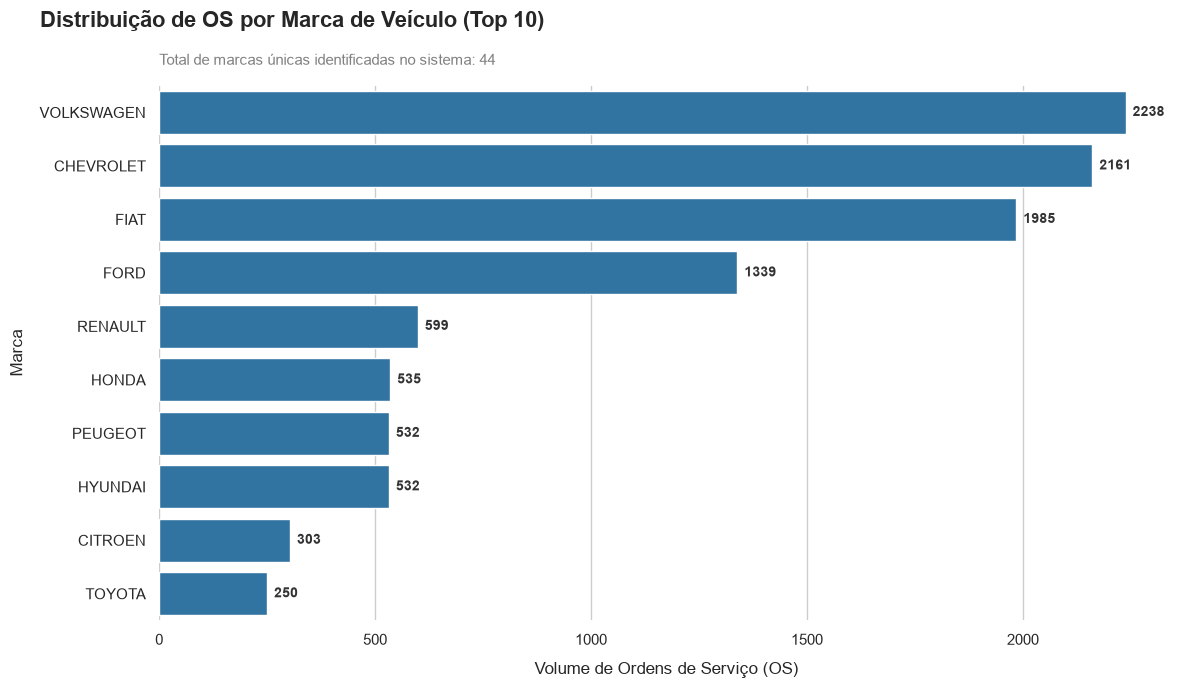

In [14]:
# Grafico Distribuição de OS por Marca de Veículo (Top 10)
top10_marcas = df["MARCA"].dropna().value_counts().head(10).reset_index()
top10_marcas.columns = ["MARCA", "Volume_OS"]

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

grafico = sns.barplot(
    x="Volume_OS",
    y="MARCA",
    data=top10_marcas,
    color="#1f77b4"  # <-- Adicione a cor desejada aqui (ex: 'blue', '#3498db', 'green')
)

for container in grafico.containers:
    grafico.bar_label(container, padding=5, fontsize=10, fontweight="bold", color="#333333")

plt.suptitle(
    "Distribuição de OS por Marca de Veículo (Top 10)", fontsize=16, fontweight="bold", x=0.04, ha="left"
)
plt.title(
    f"Total de marcas únicas identificadas no sistema: {quantidade_marcas}",
    fontsize=11,
    color="gray",
    pad=15,
    loc="left",
)
plt.xlabel("Volume de Ordens de Serviço (OS)", fontsize=12, labelpad=10)
plt.ylabel("Marca", fontsize=12, labelpad=10)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## Tempo de Permanência dos Veículos

In [15]:
# 1. Filtro de Segurança: Removendo tempos negativos ou superiores a 90 dias (2160 horas)
df_valido = df[(df["TEMPO_PERMANENCIA_H"] >= 0) & (df["TEMPO_PERMANENCIA_H"] <= 2160)].copy()

# 2. Cálculos das Métricas Principais
os_analisaveis = df_valido["ID_OS"].nunique()
media_horas = df_valido["TEMPO_PERMANENCIA_H"].mean()
mediana_horas = df_valido["TEMPO_PERMANENCIA_H"].median()

# Exibindo os resultados gerais
print("--- ESTATÍSTICAS DE TEMPO DE PERMANÊNCIA ---")
print(f"Total de OS analisáveis: {os_analisaveis}")
print(f"Permanência Média:       {media_horas:.1f} horas (aprox. {media_horas/24:.1f} dias)")
print(f"Permanência Mediana:     {mediana_horas:.1f} horas (aprox. {mediana_horas/24:.1f} dias)\n")

# 3. Criação do Quadro IV - Distribuição do Tempo de Permanência
# Definindo as condições (em horas)
condicoes = [
    df_valido["TEMPO_PERMANENCIA_H"] < 24,
    (df_valido["TEMPO_PERMANENCIA_H"] >= 24) & (df_valido["TEMPO_PERMANENCIA_H"] <= 168),
    df_valido["TEMPO_PERMANENCIA_H"] > 168
]

# Definindo os nomes das faixas
faixas = ["< 24h", "1 a 7 dias", "Mais de 7 dias"]

# Criando a nova coluna de classificação com o parâmetro 'default' como texto
df_valido["FAIXA_PERMANENCIA"] = np.select(condicoes, faixas, default="Outros")

# Agrupando e contando as OS
quadro_iv = df_valido.groupby("FAIXA_PERMANENCIA").agg(
    Quantidade_de_OS=("ID_OS", "nunique")
).reset_index()

# Calculando a porcentagem
quadro_iv["Participação (%)"] = (quadro_iv["Quantidade_de_OS"] / os_analisaveis) * 100

# 4. Ajustes Visuais da Tabela
# Forçando a ordem correta das linhas (para não ficar em ordem alfabética)
quadro_iv["FAIXA_PERMANENCIA"] = pd.Categorical(quadro_iv["FAIXA_PERMANENCIA"], categories=faixas, ordered=True)
quadro_iv = quadro_iv.sort_values("FAIXA_PERMANENCIA").reset_index(drop=True)

# Renomeando colunas para a apresentação
quadro_iv.columns = ["Faixa de Permanência", "Quantidade de OS", "Participação (%)"]

# Aplicando o estilo final para exibição no Colab
quadro_iv_formatado = quadro_iv.style.format({
    "Participação (%)": formata_pct
}).set_caption("Quadro IV - Distribuição do Tempo de Permanência dos Veículos").hide(axis="index")

# Exibe o quadro final
quadro_iv_formatado

--- ESTATÍSTICAS DE TEMPO DE PERMANÊNCIA ---
Total de OS analisáveis: 11567
Permanência Média:       78.4 horas (aprox. 3.3 dias)
Permanência Mediana:     4.0 horas (aprox. 0.2 dias)



Faixa de Permanência,Quantidade de OS,Participação (%)
< 24h,7611,"65,80%"
1 a 7 dias,2537,"21,93%"
Mais de 7 dias,1419,"12,27%"


## Distribuição temporal 

In [16]:
# 1. Agrupando os dados por Ano, contando as OS, somando a receita e calculando ticket médio
tabela_ano = df.groupby("ANO").agg(
    volume_de_os=("ID_OS", "nunique"), # Conta IDs únicos de OS
    receita_total=("VALOR TOTAL", "sum"), # Soma o valor total
    ticket_medio=("VALOR TOTAL", "mean") # Calcula o ticket médio
)

# 2. Converte o Ano para inteiro
tabela_ano.index = tabela_ano.index.astype(int)

# 3. Formatando valores para o padrão de moeda brasileiro (Reais)
tabela_ano_formatada = tabela_ano.style.format({
    "receita_total": formatar_moeda,
    "ticket_medio": formatar_moeda
})

# 3. Visualização
tabela_ano_formatada

,volume_de_os,receita_total,ticket_medio
ANO,,,
2012,712,"R$ 119.166,68","R$ 167,37"
2013,1696,"R$ 349.911,48","R$ 206,32"
2014,1445,"R$ 344.801,00","R$ 238,62"
2015,975,"R$ 352.148,38","R$ 361,18"
2016,961,"R$ 472.518,00","R$ 491,69"
2017,724,"R$ 403.202,56","R$ 556,91"
2018,664,"R$ 376.788,10","R$ 567,45"
2019,702,"R$ 450.126,99","R$ 641,21"
2020,552,"R$ 389.547,09","R$ 705,70"


## Indicadores Financeiros

In [17]:
# Calculando as métricas estatísticas sobre TODOS os tickets (coluna VALOR TOTAL)
media_ticket = df['VALOR TOTAL'].mean()
mediana_ticket = df['VALOR TOTAL'].median()
desvio_padrao = df['VALOR TOTAL'].std()

# Cálculo do Coeficiente de Variação em %
cv_ticket = (desvio_padrao / media_ticket) * 100

print("--- ESTATÍSTICAS GERAIS DO TICKET ---")
print(f"Média (Valor médio):       {formatar_moeda(media_ticket)}")
print(f"Mediana (Valor típico):    {formatar_moeda(mediana_ticket)}")
print(f"Coeficiente de Variação:   {cv_ticket:.2f}%")

--- ESTATÍSTICAS GERAIS DO TICKET ---
Média (Valor médio):       R$ 599,23
Mediana (Valor típico):    R$ 170,00
Coeficiente de Variação:   219.56%


In [18]:
# Calculando as métricas estatísticas sobre TODOS os tickets (coluna VALOR TOTAL)
media_ticket = df['VALOR TOTAL'].mean()
mediana_ticket = df['VALOR TOTAL'].median()
desvio_padrao = df['VALOR TOTAL'].std()

# Cálculo do Coeficiente de Variação em %
cv_ticket = (desvio_padrao / media_ticket) * 100

print("--- ESTATÍSTICAS GERAIS DO TICKET ---")
print(f"Média (Valor médio):       {formatar_moeda(media_ticket)}")
print(f"Mediana (Valor típico):    {formatar_moeda(mediana_ticket)}")
print(f"Coeficiente de Variação:   {cv_ticket:.2f}%")

--- ESTATÍSTICAS GERAIS DO TICKET ---
Média (Valor médio):       R$ 599,23
Mediana (Valor típico):    R$ 170,00
Coeficiente de Variação:   219.56%


### Volume de OS, Receita Total e Ticket Médio por ano

In [19]:
# 1. Agrupando os dados por Ano, contando as OS, somando a receita e calculando ticket médio
tabela_ano = df.groupby("ANO").agg(
    volume_de_os=("ID_OS", "nunique"), # Conta IDs únicos de OS
    receita_total=("VALOR TOTAL", "sum"), # Soma o valor total
    ticket_medio=("VALOR TOTAL", "mean") # Calcula o ticket médio
)

# 2. Converte o Ano para inteiro
tabela_ano.index = tabela_ano.index.astype(int)

# 3. Formatando valores para o padrão de moeda brasileiro (Reais)
tabela_ano_formatada = tabela_ano.style.format({
    "receita_total": formatar_moeda,
    "ticket_medio": formatar_moeda
})

# 3. Visualização
tabela_ano_formatada

,volume_de_os,receita_total,ticket_medio
ANO,,,
2012,712,"R$ 119.166,68","R$ 167,37"
2013,1696,"R$ 349.911,48","R$ 206,32"
2014,1445,"R$ 344.801,00","R$ 238,62"
2015,975,"R$ 352.148,38","R$ 361,18"
2016,961,"R$ 472.518,00","R$ 491,69"
2017,724,"R$ 403.202,56","R$ 556,91"
2018,664,"R$ 376.788,10","R$ 567,45"
2019,702,"R$ 450.126,99","R$ 641,21"
2020,552,"R$ 389.547,09","R$ 705,70"


### Crecimento ticket

In [20]:
ticket_2012 = tabela_ano.loc[2012, "ticket_medio"]
ticket_2025 = tabela_ano.loc[2025, "ticket_medio"]

# Calcula o percentual de crescimento
percentual_crescimento = ((ticket_2025 / ticket_2012) - 1) * 100

# Exibe o resultado
print(f"O ticket médio em 2012 era R$ {formatar_moeda(ticket_2012)}")
print(f"O ticket médio em 2025 é R$ {ticket_2025:.2f}")
print(f"O crescimento total no período foi de {percentual_crescimento:.2f}%")

O ticket médio em 2012 era R$ R$ 167,37
O ticket médio em 2025 é R$ 1567.63
O crescimento total no período foi de 836.63%


### Receita acumulada

In [21]:
receita_acumulada = tabela_ano["receita_total"].sum()

receita_media_anual = tabela_ano["receita_total"].mean()

print(f"A receita acumulada foi de R$ {formatar_moeda(receita_acumulada)}")
print(f"A receita média anual foi de R$ {formatar_moeda(receita_media_anual)}")

A receita acumulada foi de R$ R$ 6.936.658,20
A receita média anual foi de R$ R$ 462.443,88


### OS por mes

In [22]:
# 1. Agrupar os para cada combinação de ANO e MES
os_por_ano_mes = df.groupby(["ANO", "MES"]).agg(
    volume_de_os=("ID_OS", "nunique") # Conta IDs únicos de OS
).reset_index()

# 2. Agrupa apenas por MES e tira média histórica
media_os_por_mes = os_por_ano_mes.groupby("MES").agg(
    media_historica_os=("volume_de_os", "mean")
).reset_index()

media_os_por_mes

,MES,media_historica_os
0,1.0,73.428571
1,2.0,63.428571
2,3.0,63.928571
3,4.0,67.076923
4,5.0,68.615385
5,6.0,68.461538
6,7.0,72.857143
7,8.0,75.785714
8,9.0,73.214286
9,10.0,73.928571


## Perfil da Carteira de Clientes

In [23]:
# 1. Agrupando os dados para contar quantas OS cada cliente tem
os_por_cliente = df.groupby("ID_Cliente").agg(
    QTD_OS=("ID_OS", "nunique")
).reset_index()

# 2. Cálculos das Métricas Principais
total_clientes = os_por_cliente["ID_Cliente"].nunique()
media_os_cliente = os_por_cliente["QTD_OS"].mean()
max_os = os_por_cliente["QTD_OS"].max()

# Descobrindo qual é o ID do cliente com o maior número de OS
cliente_top_id = os_por_cliente.loc[os_por_cliente["QTD_OS"].idxmax(), "ID_Cliente"]

# Exibindo os resultados gerais iniciais
print("--- MÉTRICAS GERAIS DA CARTEIRA ---")
print(f"Total de Clientes Únicos: {total_clientes}")
print(f"Média de OS por Cliente:  {media_os_cliente:.2f}".replace(".", ","))
print(f"Cliente com mais OS:      ID {cliente_top_id} (Total de {max_os} OS)\n")

# 3. Classificação dos Perfis de Clientes
# Definindo as condições matemáticas para as faixas de OS
condicoes_perfil = [
    os_por_cliente["QTD_OS"] == 1,
    (os_por_cliente["QTD_OS"] >= 2) & (os_por_cliente["QTD_OS"] <= 5),
    os_por_cliente["QTD_OS"] > 5
]

# Definindo os nomes das faixas
faixas_perfil = ["Esporádicos (1 OS)", "Recorrentes (2 a 5 OS)", "Fidelizados (> 5 OS)"]

# Aplicando a classificação
os_por_cliente["PERFIL_CLIENTE"] = np.select(condicoes_perfil, faixas_perfil, default="Outros")

# 4. Criando o Quadro de Distribuição
quadro_perfil = os_por_cliente.groupby("PERFIL_CLIENTE").agg(
    Quantidade_de_Clientes=("ID_Cliente", "nunique")
).reset_index()

# Calculando a porcentagem de participação na carteira
quadro_perfil["Participação (%)"] = (quadro_perfil["Quantidade_de_Clientes"] / total_clientes) * 100

# 5. Ajustes Visuais e Formatação
quadro_perfil["PERFIL_CLIENTE"] = pd.Categorical(quadro_perfil["PERFIL_CLIENTE"], categories=faixas_perfil, ordered=True)
quadro_perfil = quadro_perfil.sort_values("PERFIL_CLIENTE").reset_index(drop=True)

# Renomeando as colunas
quadro_perfil.columns = ["Perfil do Cliente", "Quantidade de Clientes", "Participação (%)"]

# Aplicando o estilo
quadro_perfil_formatado = quadro_perfil.style.format({
    "Participação (%)": formata_pct
}).hide(axis="index")

# Exibe o quadro final
quadro_perfil_formatado

--- MÉTRICAS GERAIS DA CARTEIRA ---
Total de Clientes Únicos: 2265
Média de OS por Cliente:  5,11
Cliente com mais OS:      ID CLI_0016 (Total de 1132 OS)



Perfil do Cliente,Quantidade de Clientes,Participação (%)
Esporádicos (1 OS),1230,"54,30%"
Recorrentes (2 a 5 OS),704,"31,08%"
Fidelizados (> 5 OS),331,"14,61%"


## Tempo Médio entre Atendimentos Consecutivos

In [24]:
# 1. Garantindo que a coluna de data de entrada esteja no formato correto de data
df["ENTRADA VEICULO"] = pd.to_datetime(df["ENTRADA VEICULO"], errors="coerce")


# DIMENSÃO 1: POR CLIENTE

# Ordena por Cliente e pela Data (do mais antigo para o mais novo)
df_cliente = df.sort_values(by=["ID_Cliente", "ENTRADA VEICULO"]).copy()

# Calcula a diferença em dias entre a OS atual e a anterior do mesmo cliente
df_cliente["DIAS_INTERVALO"] = df_cliente.groupby("ID_Cliente")["ENTRADA VEICULO"].diff().dt.days

# Remove os valores vazios (que representam a 1ª vez do cliente na oficina, logo não há par)
pares_cliente = df_cliente.dropna(subset=["DIAS_INTERVALO"]).copy()

qtd_pares_cliente = len(pares_cliente)
media_cliente = pares_cliente["DIAS_INTERVALO"].mean()
mediana_cliente = pares_cliente["DIAS_INTERVALO"].median()
std_cliente = pares_cliente["DIAS_INTERVALO"].std()


# DIMENSÃO 2: POR VEÍCULO (PLACA)

# Mesma lógica, mas agrupando pela Placa do veículo
df_veiculo = df.sort_values(by=["ID_PLACA", "ENTRADA VEICULO"]).copy()
df_veiculo["DIAS_INTERVALO"] = df_veiculo.groupby("ID_PLACA")["ENTRADA VEICULO"].diff().dt.days
pares_veiculo = df_veiculo.dropna(subset=["DIAS_INTERVALO"]).copy()

qtd_pares_veiculo = len(pares_veiculo)
media_veiculo = pares_veiculo["DIAS_INTERVALO"].mean()
mediana_veiculo = pares_veiculo["DIAS_INTERVALO"].median()
std_veiculo = pares_veiculo["DIAS_INTERVALO"].std()


# EXIBINDO AS MÉTRICAS

print("--- MÉTRICAS: CICLO DE RETORNO ---")
print(">> DIMENSÃO: CLIENTE")
print(f"Número de pares consecutivos: {qtd_pares_cliente}")
print(f"Intervalo Médio:              {media_cliente:.1f} dias")
print(f"Mediana (Valor Típico):       {mediana_cliente:.1f} dias")
print(f"Desvio Padrão:                {std_cliente:.1f} dias\n")

print(">> DIMENSÃO: VEÍCULO")
print(f"Número de pares consecutivos: {qtd_pares_veiculo}")
print(f"Intervalo Médio:              {media_veiculo:.1f} dias")
print(f"Mediana (Valor Típico):       {mediana_veiculo:.1f} dias")
print(f"Desvio Padrão:                {std_veiculo:.1f} dias\n")

--- MÉTRICAS: CICLO DE RETORNO ---
>> DIMENSÃO: CLIENTE
Número de pares consecutivos: 9302
Intervalo Médio:              119.7 dias
Mediana (Valor Típico):       28.0 dias
Desvio Padrão:                283.5 dias

>> DIMENSÃO: VEÍCULO
Número de pares consecutivos: 5880
Intervalo Médio:              196.6 dias
Mediana (Valor Típico):       99.0 dias
Desvio Padrão:                308.1 dias



In [25]:
# Definindo as condições para as faixas (agora incluindo "90 a 365 dias")
condicoes_intervalo = [
    pares_cliente["DIAS_INTERVALO"] < 30,
    (pares_cliente["DIAS_INTERVALO"] >= 30) & (pares_cliente["DIAS_INTERVALO"] <= 90),
    (pares_cliente["DIAS_INTERVALO"] > 90) & (pares_cliente["DIAS_INTERVALO"] <= 365),
    pares_cliente["DIAS_INTERVALO"] > 365
]

# Textos das faixas
faixas_intervalo = ["Menos de 30 dias", "30 a 90 dias", "90 a 365 dias", "Mais de 365 dias"]

# Criando a coluna de classificação
pares_cliente["FAIXA_INTERVALO"] = np.select(condicoes_intervalo, faixas_intervalo, default="Outros")

# Agrupando para montar o quadro
quadro_vi = pares_cliente.groupby("FAIXA_INTERVALO").agg(
    Quantidade_de_Pares=("ID_OS", "count")
).reset_index()

# Calculando a participação
quadro_vi["Participação (%)"] = (quadro_vi["Quantidade_de_Pares"] / qtd_pares_cliente) * 100

# Ordenando as faixas cronologicamente (e não ordem alfabética)
quadro_vi["FAIXA_INTERVALO"] = pd.Categorical(quadro_vi["FAIXA_INTERVALO"], categories=faixas_intervalo, ordered=True)
quadro_vi = quadro_vi.sort_values("FAIXA_INTERVALO").reset_index(drop=True)

# Renomeando as colunas do quadro final
quadro_vi.columns = ["Faixa de Intervalo", "Quantidade de Pares", "Participação (%)"]

# Estilizando o Quadro VI
quadro_vi_formatado = quadro_vi.style.format({
    "Participação (%)": formata_pct
}).set_caption("Quadro VI - Distribuição dos Intervalos entre Atendimentos Consecutivos (Por Cliente)").hide(axis="index")

# Exibindo
quadro_vi_formatado

Faixa de Intervalo,Quantidade de Pares,Participação (%)
Menos de 30 dias,4731,"50,86%"
30 a 90 dias,1820,"19,57%"
90 a 365 dias,2031,"21,83%"
Mais de 365 dias,720,"7,74%"
